# 🎮 Team Liquid: E-sports Performance Analysis
> **Data Science Project:** Extraction and Processing of Liquipedia Datasets

## 1. Project Overview
This project focuses on the extraction, cleaning, and preparation of competitive data from **Team Liquid**, one of the world's most successful e-sports organizations. The goal is to build a robust dataset to analyze prize money across multiple titles.

---

## 2. Data Sourcing
The raw data was curated from [Liquipedia.net](https://liquipedia.net), the premier wiki for competitive gaming.

**Key Data Points:**
* **Games Chosed:** Dota 2, League of Legends, Rainbows Six, and Counter-Strike.
* **Attributes:** Tournament tiers, prize pools.

---

In [57]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import re

Liquid_dota = pd.read_html("https://liquipedia.net/dota2/Team_Liquid/Results")[0]
Liquid_lol  = pd.read_html("https://liquipedia.net/leagueoflegends/Team_Liquid/Results")[0]
Liquid_csgo = pd.read_html("https://liquipedia.net/counterstrike/Team_Liquid/Results")[0]
Liquid_rainbow6 = pd.read_html("https://liquipedia.net/rainbowsix/Team_Liquid/Results")[0]

## 3. Data Processing Pipeline

### 🧹 Cleaning & Pre-processing
* **Null Value Handling:** Managing missing tournament dates and "TBD" (To Be Determined) results.
* **Feature Standardization:** Normalizing currency strings (e.g., converting `50,000` to `50000.00`).

### 🏗️ Data Wrangling
* **Merging:** Combining disparate datasets from different game titles into a unified organizational view.
* **Categorization:** Mapping tournament tiers (Premier, Major, Minor) into ordinal numerical values for correlation analysis.

---

In [58]:
Liquid_csgo.head()
Liquid_csgo.drop(columns=['G.', 'Type'], inplace=True)
Liquid_csgo.head()

/tmp/ipykernel_49942/540630403.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  Liquid_csgo.drop(columns=['G.', 'Type'], inplace=True)


Date        Place    Tier Tournament  \
         2026         2026    2026       2026   
0  2026-05-21   9th - 12th  S-Tier        NaN   
1  2026-05-13   9th - 12th  S-Tier        NaN   
2  2026-04-14  13th - 16th  S-Tier        NaN   
3  2026-03-31    7th - 8th  B-Tier        NaN   
4  2026-03-22   9th - 12th  S-Tier        NaN   

                                      Result          Prize  \
                               2026.1   2026 2026.1    2026   
0          CS Asia Championships 2026  1 : 2    NaN  $4,000   
1  Intel Extreme Masters Atlanta 2026  0 : 2    NaN  $5,000   
2      Intel Extreme Masters Rio 2026  0 : 2    NaN  $4,000   
3                   DraculaN Season 6  0 : 2    NaN       -   
4              BLAST Open Spring 2026  0 : 2    NaN  $7,500   

  Unnamed: 10_level_0 Unnamed: 11_level_0  ... Unnamed: 32_level_0  \
                 2026                2026  ...                2026   
0                 NaN                 NaN  ...                 NaN   
1                 NaN                 NaN  ...                 NaN   
2                 NaN                 NaN  ...                 NaN   
3                 NaN                 NaN  ...                 NaN   
4                 NaN                 NaN  ...                 NaN   

  Unnamed: 33_level_0 Unnamed: 34_level_0 Unnamed: 35_level_0  \
                 2026                2026                2026   
0                 NaN                 NaN                 NaN   
1                 NaN                 NaN                 NaN   
2                 NaN                 NaN                 NaN   
3                 NaN                 NaN                 NaN   
4                 NaN                 NaN                 NaN   

  Unnamed: 36_level_0 Unnamed: 37_level_0 Unnamed: 38_level_0  \
                 2026                2026                2026   
0                 NaN                 NaN                 NaN   
1                 NaN                 NaN                 NaN   
2                 NaN                 NaN                 NaN   
3                 NaN                 NaN                 NaN   
4                 NaN                 NaN                 NaN   

  Unnamed: 39_level_0 Unnamed: 40_level_0 Unnamed: 41_level_0  
                 2026                2026                2026  
0                 NaN                 NaN                 NaN  
1                 NaN                 NaN                 NaN  
2                 NaN                 NaN                 NaN  
3                 NaN                 NaN                 NaN  
4                 NaN                 NaN                 NaN  

[5 rows x 40 columns]

In [59]:

urls_jogos = {
    "Dota 2": "https://liquipedia.net/dota2/Team_Liquid/Results",
    "League of Legends": "https://liquipedia.net/leagueoflegends/Team_Liquid/Results",
    "Counter-Strike": "https://liquipedia.net/counterstrike/Team_Liquid/Results",
    "Rainbow Six": "https://liquipedia.net/rainbowsix/Team_Liquid/Results"
}

dataframes_limpos = {}

for jogo, url in urls_jogos.items():
    try:
        tabelas_normais = pd.read_html(url)
        df = tabelas_normais[0].copy()
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
            
        tabelas_links = pd.read_html(url, extract_links="body")
        df_links = tabelas_links[0].copy()
        
        if isinstance(df_links.columns, pd.MultiIndex):
            df_links.columns = df_links.columns.get_level_values(0)
        
        col_torneio = 'Tournament' if 'Tournament' in df_links.columns else 'Tournaments'
        
        coluna_isolada = df_links[col_torneio]
        if isinstance(coluna_isolada, pd.DataFrame):
            coluna_isolada = coluna_isolada.iloc[:, -1]
        
        link_cru = coluna_isolada.str[1]
            
        df['Tournament_Link'] = link_cru.apply(
            lambda x: "https://liquipedia.net" + x if isinstance(x, str) and x.startswith('/') else x
        )
        
        if col_torneio in df.columns:
            coluna_texto_isolada = df[col_torneio]
            if isinstance(coluna_texto_isolada, pd.DataFrame):
                coluna_texto_isolada = coluna_texto_isolada.iloc[:, -1]
                
            if coluna_texto_isolada.apply(lambda x: isinstance(x, tuple)).any():
                df[col_torneio] = coluna_texto_isolada.str[0]
            else:
                df[col_torneio] = coluna_texto_isolada
                
        df['Game'] = jogo
        
        dataframes_limpos[jogo] = df
        print(f"✅ {jogo} processado com sucesso!")
        
    except Exception as e:
        print(f"❌ Erro ao processar o jogo {jogo}: {e}")


✅ Dota 2 processado com sucesso!
✅ League of Legends processado com sucesso!
✅ Counter-Strike processado com sucesso!
✅ Rainbow Six processado com sucesso!


In [60]:
Liquid_dota = dataframes_limpos["Dota 2"].copy()
Liquid_lol  = dataframes_limpos["League of Legends"].copy()
Liquid_csgo = dataframes_limpos["Counter-Strike"].copy()
Liquid_rainbow6 = dataframes_limpos["Rainbow Six"].copy()

In [61]:
Liquid_csgo.head()

,Date,Place,Tier,Type,G.,Tournament,Tournament,Result,Result,Prize,...,Unnamed: 34_level_0,Unnamed: 35_level_0,Unnamed: 36_level_0,Unnamed: 37_level_0,Unnamed: 38_level_0,Unnamed: 39_level_0,Unnamed: 40_level_0,Unnamed: 41_level_0,Tournament_Link,Game
0,2026-05-21,9th - 12th,S-Tier,Offline,NaN,CS Asia Championships 2026,CS Asia Championships 2026,1 : 2,NaN,"$4,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://liquipedia.net/counterstrike/CS_Asia_C...,Counter-Strike
1,2026-05-13,9th - 12th,S-Tier,Offline,NaN,Intel Extreme Masters Atlanta 2026,Intel Extreme Masters Atlanta 2026,0 : 2,NaN,"$5,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://liquipedia.net/counterstrike/Intel_Ext...,Counter-Strike
2,2026-04-14,13th - 16th,S-Tier,Offline,NaN,Intel Extreme Masters Rio 2026,Intel Extreme Masters Rio 2026,0 : 2,NaN,"$4,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://liquipedia.net/counterstrike/Intel_Ext...,Counter-Strike
3,2026-03-31,7th - 8th,B-Tier,Offline,NaN,DraculaN Season 6,DraculaN Season 6,0 : 2,NaN,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://liquipedia.net/counterstrike/DraculaN/...,Counter-Strike
4,2026-03-22,9th - 12th,S-Tier,Offline,NaN,BLAST Open Spring 2026,BLAST Open Spring 2026,0 : 2,NaN,"$7,500",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://liquipedia.net/counterstrike/BLAST/Ope...,Counter-Strike


In [62]:
# Data Cleaning
import datetime as dt

# Function for cleaning and preparing the data
def prepare_game(df):
    df.columns = df.columns.get_level_values(0)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df.copy()
    df['Tournament'] = df.iloc[:, 3].fillna(df.iloc[:, 4])
    df['Result'] = df.iloc[:, 5].fillna(df.iloc[:, 6])
    df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    df = df.replace('-', np.nan)
    colunas_desejadas = ['Date', 'Place', 'Tier', 'Tournament', 'Result', 'Prize', 'Tournament_Link']
    df = df[colunas_desejadas]
    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['Date'].astype(str).str.contains('-', na=False)]
    df.Date = pd.to_datetime(df.Date, format='%Y-%m-%d')
    df.Prize = df.Prize.str.replace(r'[^\d.]', '', regex=True).astype(float)

    
    return df.reset_index(drop=True)

# Prepare the data for each game
Liquid_dota = prepare_game(Liquid_dota)
Liquid_lol = prepare_game(Liquid_lol)
Liquid_csgo = prepare_game(Liquid_csgo)
Liquid_rainbow6 = prepare_game(Liquid_rainbow6)

Liquid_dota.head()

,Date,Place,Tier,Tournament,Result,Prize,Tournament_Link
0,2026-05-20,9th - 12th,Tier 1,DreamLeague Season 29,1 : 2,20000.0,https://liquipedia.net/dota2/DreamLeague/29
1,2026-04-25,4th,Tier 1,PGL Wallachia Season 8,1 : 2,80000.0,https://liquipedia.net/dota2/PGL/Wallachia/8
2,2026-04-14,3rd,Qualifier,DreamLeague Season 29: Western Europe Closed Q...,2 : 1,NaN,https://liquipedia.net/dota2/DreamLeague/29/We...
3,2026-04-10,5th - 6th,Tier 2,PREMIER SERIES,1 : 2,2500.0,https://liquipedia.net/dota2/NarodCast/PREMIER...
4,2026-03-15,2nd,Tier 1,PGL Wallachia Season 7,2 : 3,175000.0,https://liquipedia.net/dota2/PGL/Wallachia/7


## 4. Data Dictionary (Preview)

| Column | Description | Data Type |
| :--- | :--- | :--- |
| `date` | Date of the match or tournament conclusion | Datetime |
| `game` | The specific e-sport title | String |
| `placement` | Final standing in the tournament | Integer |
| `prize_usd` | Total winnings in USD | Float |

---

## 5. Roadmap
- [ ] **Exploratory Data Analysis (EDA):** Identify which game is currently the most profitable for the org.
- [ ] **Visualization:** Create a time-series dashboard of total earnings.

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

#Dota
# Liquid_dota = Liquid_dota[Liquid_dota['Tier'] == 'Tier 1']
Liquid_dota['Prize_Clean'] = (
    Liquid_dota['Prize']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace(['-', 'nan', 'NaN'], '0')
    .astype(float)
)
Liquid_dota = Liquid_dota.sort_values('Date')
# Create a filtered DataFrame that excludes tournaments with "International" in the name, because the prize pools of The International are outliers that can skew the cumulative prize pool growth over time.
# Symbol ~ indicates negation, str.contains busca por "International" e na=False evita erros com valores nulos
Liquid_dota_filtered = Liquid_dota[~Liquid_dota['Tournament'].str.contains('International', na=False)]
Liquid_dota['Cumulative_Prize'] = Liquid_dota['Prize_Clean'].cumsum()  #Cumulative sum for the filtered DataFrame
Liquid_dota_filtered['Cumulative_Prize'] = Liquid_dota_filtered['Prize_Clean'].cumsum() #Cumulative sum for the filtered DataFrame


#LOL
# Liquid_lol = Liquid_lol[Liquid_lol['Tier'] == ('S-Tier' or 'A-Tier')]
Liquid_lol['Prize_Clean'] = (
    Liquid_lol['Prize']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace(['-', 'nan', 'NaN'], '0')
    .astype(float)
)
Liquid_lol = Liquid_lol.sort_values('Date')
Liquid_lol['Cumulative_Prize'] = Liquid_lol['Prize_Clean'].cumsum() #Cumulative sum for the filtered DataFrame

# CSGO and CS2
# Liquid_csgo = Liquid_csgo[Liquid_csgo['Tier'] == 'S-Tier']
Liquid_csgo['Prize_Clean'] = (
    Liquid_csgo['Prize']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace(['-', 'nan', 'NaN'], '0')
    .astype(float)
)
Liquid_csgo = Liquid_csgo.sort_values('Date')
Liquid_csgo['Cumulative_Prize'] = Liquid_csgo['Prize_Clean'].cumsum() #Cumulative sum for the filtered DataFrame

#Rainbow6
# Liquid_rainbow6 = Liquid_rainbow6[Liquid_rainbow6['Tier'] == ('S-Tier' or 'A-Tier')]
Liquid_rainbow6['Prize_Clean'] = (
    Liquid_rainbow6['Prize']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace(['-', 'nan', 'NaN'], '0')
    .astype(float)
)
Liquid_rainbow6 = Liquid_rainbow6.sort_values('Date')
Liquid_rainbow6['Cumulative_Prize'] = Liquid_rainbow6['Prize_Clean'].cumsum() #Cumulative sum for the filtered DataFrame

Liquid_dota['Game'] = 'Dota 2'
Liquid_dota_filtered['Game'] = 'Dota 2 Without Internationals'
Liquid_lol['Game'] = 'LoL'
Liquid_csgo['Game'] = 'CS:GO/CS2'
Liquid_rainbow6['Game'] = 'R6'

dfs = [Liquid_dota, Liquid_dota_filtered, Liquid_lol, Liquid_csgo, Liquid_rainbow6]

df_liquid = pd.concat(dfs, ignore_index=True)

df_liquid['Date'] = pd.to_datetime(df_liquid['Date'])

df_liquid = df_liquid.sort_values(['Game', 'Date'])

#Order by Game and Date, then calculate cumulative sum of Prize_Clean for each Game
df_liquid['Cumulative_Prize'] = df_liquid.groupby('Game')['Prize_Clean'].cumsum()


/tmp/ipykernel_49942/3081763835.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Liquid_dota_filtered['Cumulative_Prize'] = Liquid_dota_filtered['Prize_Clean'].cumsum() #Cumulative sum for the filtered DataFrame
/tmp/ipykernel_49942/3081763835.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Liquid_dota_filtered['Game'] = 'Dota 2 Without Internationals'


In [64]:

df_liquid.head()


,Date,Place,Tier,Tournament,Result,Prize,Tournament_Link,Prize_Clean,Cumulative_Prize,Game
478,2015-01-25,5th - 6th,S-Tier,Offline,Offline,NaN,https://liquipedia.net/counterstrike/MLG/Aspen...,0.0,0.0,CS:GO/CS2
479,2015-02-01,3rd - 4th,A-Tier,Offline,Offline,1000.0,https://liquipedia.net/counterstrike/Clutch_Co...,1000.0,1000.0,CS:GO/CS2
480,2015-02-15,13th - 16th,Qualifier,Offline,Offline,NaN,https://liquipedia.net/counterstrike/ESL/One/2...,0.0,1000.0,CS:GO/CS2
481,2015-03-01,2nd,B-Tier,Online,Online,1000.0,https://liquipedia.net/counterstrike/IBUYPOWER...,1000.0,2000.0,CS:GO/CS2
482,2015-03-06,6th,Qualifier,Online,Online,NaN,https://liquipedia.net/counterstrike/ESEA/Seas...,0.0,2000.0,CS:GO/CS2


In [65]:
df_liquid.to_csv("liquid_data.csv")

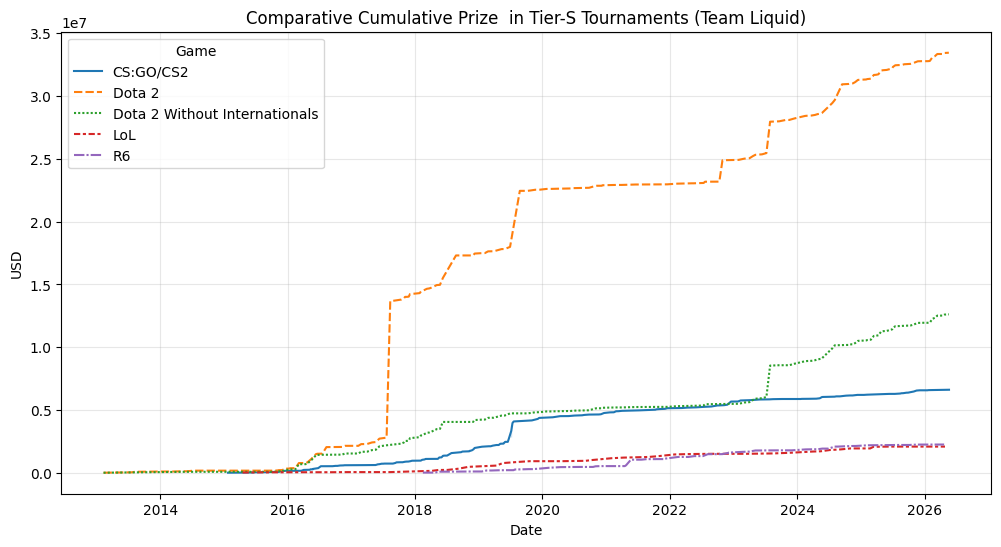

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_liquid, x='Date', y='Cumulative_Prize', hue='Game', style='Game', markersize=10)

plt.title('Comparative Cumulative Prize  in Tier-S Tournaments (Team Liquid)')
plt.ylabel('USD')
plt.grid(True, alpha=0.3)
plt.show()

In [67]:
import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
from pandas import options

df_liquid = df_liquid.sort_values(['Date', 'Game'])
dates = pd.to_datetime(df_liquid['Date'].unique())
options = [(date.strftime('%b %Y'), date) for date in dates]

# Slider with the unique dates from the dataset, formatted as "Month Year" for better readability
date_slider = widgets.SelectionRangeSlider(
    options=options,
    index=(0, len(options) - 1),
    description='Período:',
    layout={'width': '500px'},
    continuous_update=False
)

game_list = sorted(df_liquid['Game'].unique().tolist()) # Lista of all unique games in the dataset, sorted alphabetically
game_selector = widgets.SelectMultiple(
    options=game_list,
    value=game_list, # Begin with all games selected
    description='Jogos:',
    rows=len(game_list),
    layout={'width': '500px'}
)

# Output widgets to display the plot and the table
output_plot = widgets.Output()
output_table = widgets.Output()

# Funcation to update the dashboard based on the selected date range and games
def update_dashboard(date_range, selected_games):
    start_date, end_date = date_range
    
    # Filter for the selected date range and games
    mask = (
        (df_liquid['Date'] >= start_date) & 
        (df_liquid['Date'] <= end_date) & 
        (df_liquid['Game'].isin(selected_games))
    )
    df_filtered = df_liquid.loc[mask].copy()

    df_filtered = df_filtered.sort_values(['Game', 'Date'])

    df_filtered['Cumulative_Prize'] = df_filtered.groupby('Game')['Prize_Clean'].cumsum()
    
    # Clean up previous outputs before displaying new ones
    with output_plot:
        clear_output(wait=True)
        if df_filtered.empty:
            print("None data found for the selected filters.")
        else:
            plt.figure(figsize=(12, 5))
            # Seaborn adjusts colors automatically based on the 'hue'
            sns.lineplot(data=df_filtered, x='Date', y='Cumulative_Prize', hue='Game', marker='o')
            plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
            plt.title(f'Cumulative Prize in Tier-S Tournaments ({start_date.year} - {end_date.year})')
            plt.ylabel('USD')
            plt.grid(True, alpha=0.2)
            plt.xticks(rotation=45)
            plt.show()

    with output_table:
        clear_output(wait=True)
        if not df_filtered.empty:
            # Show only the top 5 results based on Prize, sorted in descending order
            total_periodo = df_filtered['Prize_Clean'].sum()
            display(df_filtered[['Date', 'Game', 'Tournament', 'Place', 'Prize']]
                    .sort_values('Prize', ascending=False)
                    .reset_index(drop=True).head(5))

# Interact to link the widgets with the update function
widgets.interact(update_dashboard, date_range=date_slider, selected_games=game_selector)

# Show the outputs (the interact takes care of the widgets, we take care of the outputs)
display(output_plot, output_table)

interactive(children=(SelectionRangeSlider(continuous_update=False, description='Período:', index=(0, 578), la…

Output()

Output()

In [68]:
import plotly.express as px
import plotly.graph_objects as go

df_liquid = pd.concat(dfs, ignore_index=True)

df_liquid['Date'] = pd.to_datetime(df_liquid['Date'])

df_liquid = df_liquid.sort_values(['Game', 'Date'])

#Order by Game and Date, then calculate cumulative sum of Prize_Clean for each Game
df_liquid['Cumulative_Prize'] = df_liquid.groupby('Game')['Prize_Clean'].cumsum()


def update_dashboard_plotly(date_range, selected_games):
    start_date, end_date = date_range
    
    # Filter for the selected date range and games
    mask = (
        (df_liquid['Date'] >= start_date) & 
        (df_liquid['Date'] <= end_date) & 
        (df_liquid['Game'].isin(selected_games))
    )
    df_filtered = df_liquid.loc[mask].copy()
    
    if df_filtered.empty:
        print("Period without data.")
        return

    # Recompute cumulative prize for the filtered DataFrame, just in case the filtering changed the order or the sums
    df_filtered = df_filtered.sort_values(['Game', 'Date'])
    df_filtered['Cumulative_Prize'] = df_filtered.groupby('Game')['Prize_Clean'].cumsum()

    # Interactive line plot with Plotly Express
    
    fig = px.line(
        df_filtered, 
        x="Date", 
        y="Cumulative_Prize", 
        color="Game",
        # 'hover_data' defines what appears when hovering the mouse
        hover_data={
            "Tournament": True, 
            "Place": True, 
            "Prize_Clean": ":$,.2f", # Prize formatted as currency
            "Cumulative_Prize": ":$,.2f",
            "Date": "|%d %b, %Y" # Date formatted for better readability
        },
        title=f"Cumulative Earnings of Team Liquid",
        markers=True,
        width=1200,
        height=600
    )

    # Fine layout adjustments
    fig.update_layout(
        xaxis_title="Date",
        yaxis_title="Sum of Prize (USD)",
        hovermode="x unified" # Show all games for that date at the same time
    )

    fig.show()

# Conect the new update function to the widgets
widgets.interact(update_dashboard_plotly, date_range=date_slider, selected_games=game_selector)

interactive(children=(SelectionRangeSlider(continuous_update=False, description='Período:', index=(0, 578), la…

<function __main__.update_dashboard_plotly(date_range, selected_games)>

However, as observed, a direct comparison between different games may be misleading. The frequency of tournaments varies significantly across titles; for instance, Counter-Strike and Dota 2 typically have a much higher volume of competitions than Rainbow Six or League of Legends. Therefore, a more robust metric would involve comparing different teams within the same game or performing specific pairings, such as LoL vs. R6 or CS vs. Dota, rather than a broad cross-game analysis.

Another performance metric, particularly for comparing CS and Dota, would be tournament placements. Since Dota’s prize pools often dwarf those of other games, cumulative earnings metrics tend to be heavily skewed and may not accurately reflect relative performance.

In [69]:
print(df_liquid[df_liquid['Game'] == 'Dota 2']['Place'].value_counts())

Place
1st            42
2nd            38
3rd            26
5th - 6th      22
4th            22
3rd - 4th      12
5th - 8th      10
7th - 8th      10
9th - 10th      7
9th - 12th      6
1st - 2nd       4
11th - 12th     4
6th             2
13th - 16th     2
7th             2
L               2
13th - 14th     2
5th - 9th       1
7th - 11th      1
7th - 9th       1
3rd - 12th      1
7th - 10th      1
1st - 4th       1
15th - 16th     1
8th             1
9th - 13th      1
9th - 16th      1
Name: count, dtype: int64


To normalize the comparison between CS and Dota, I focused exclusively on elite performance by tracking top-tier placements (1st to 3rd/4th). This approach filters out the volatility of varying prize structures and highlights team consistency in reaching the final stages of major tournaments.

In [70]:
pattern = r'(?<!\d)(1st|2nd|3rd)'

dota_standing_filter = df_liquid[df_liquid['Game'] == 'Dota 2']['Place'].str.contains(pattern, na=False)

# Aplicando o filtro e contando as ocorrências totais
dota_standing = df_liquid[df_liquid['Game'] == 'Dota 2']['Place'][dota_standing_filter].value_counts()

csgo_standing_filter = df_liquid[df_liquid['Game'] == 'CS:GO/CS2']['Place'].str.contains(pattern, na=False)

# Aplicando o filtro e contando as ocorrências totais
csgo_standing = df_liquid[df_liquid['Game'] == 'CS:GO/CS2']['Place'][csgo_standing_filter].value_counts()

print(dota_standing)
print(csgo_standing)

Place
1st           42
2nd           38
3rd           26
3rd - 4th     12
1st - 2nd      4
3rd - 12th     1
1st - 4th      1
Name: count, dtype: int64
Place
2nd          43
1st          34
3rd - 4th    26
3rd          15
1st - 2nd     7
1st - 4th     3
3rd - 5th     2
1st - 8th     2
1st - 3rd     1
Name: count, dtype: int64


/tmp/ipykernel_49942/226402611.py:3: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.

/tmp/ipykernel_49942/226402611.py:8: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que você tenha uma coluna 'Date' em datetime
df_liquid['Year'] = pd.to_datetime(df_liquid['Date']).dt.year

# Criamos uma coluna simplificada para o pódio
def simplificar_podio(row):
    import re
    # Busca 1st, 2nd ou 3rd que não tenham números antes (seu regex anterior)
    match = re.search(r'(?<!\d)(1st|2nd|3rd)', str(row))
    return match.group(0) if match else None

df_liquid['Podium'] = df_liquid['Place'].apply(simplificar_podio)

# Filtramos apenas os anos que tiveram pódios
df_podio = df_liquid[df_liquid['Podium'].notna()].copy()

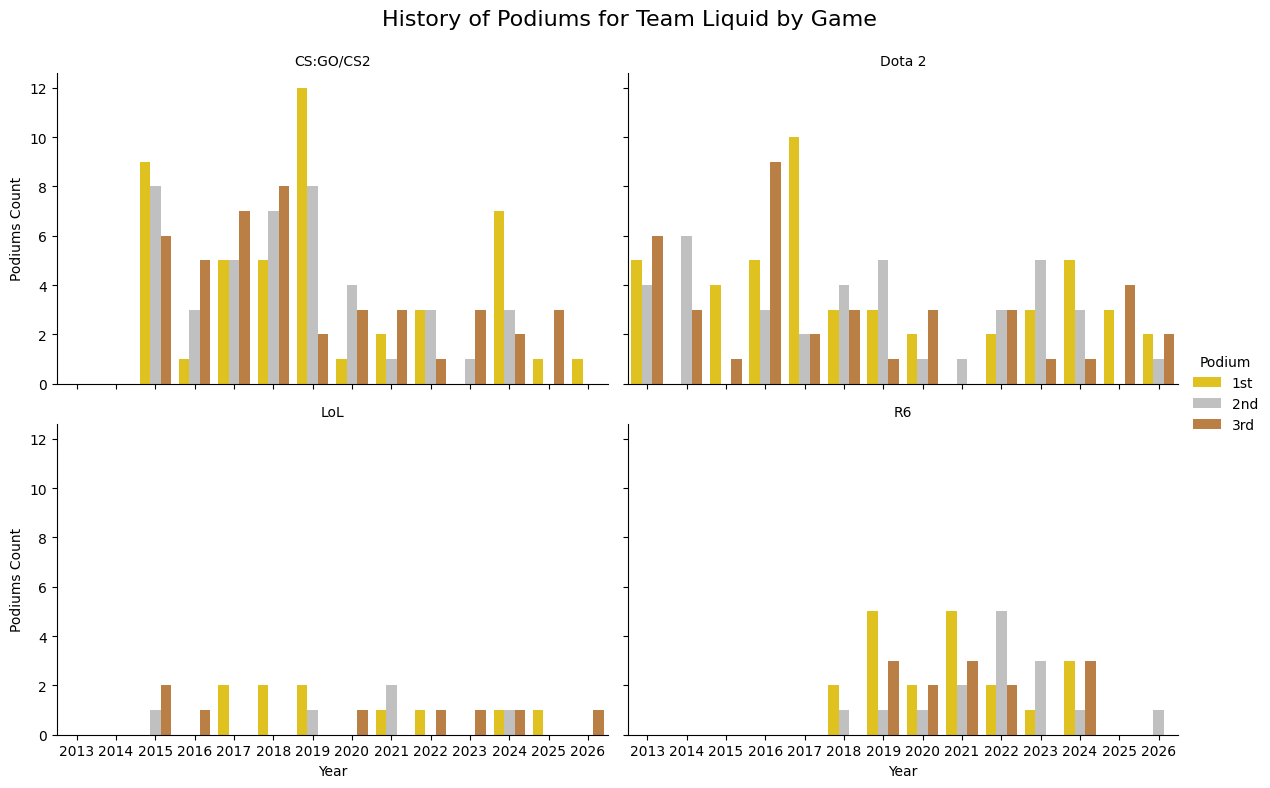

In [72]:
# Cruzamos os dados: Linhas = Ano, Colunas = Posição
contagem_anual = pd.crosstab(df_podio['Year'], df_podio['Podium'])

# Reordenar colunas para ficar 1st -> 2nd -> 3rd
cols = [c for c in ['1st', '2nd', '3rd'] if c in contagem_anual.columns]
contagem_anual = contagem_anual[cols]

games_target = ['Dota 2', 'CS:GO/CS2', 'LoL', 'R6'] # Pega os 6 principais jogos
df_plot = df_podio[df_podio['Game'].isin(games_target)].copy() # Filtra apenas os jogos de interesse
df_plot['Podium'] = pd.Categorical(df_plot['Podium'], categories=['1st', '2nd', '3rd'], ordered=True)
# Plotando
g = sns.catplot(
                    data=df_plot, 
                    x='Year', 
                    hue='Podium', 
                    col='Game', 
                    kind='count', 
                    col_wrap=2,
                    palette={'1st': '#FFD700', '2nd': '#C0C0C0', '3rd': '#CD7F32'},
                    height=4, 
                    aspect=1.5) # Cores Ouro, Prata, Bronze

# plt.xticks(rotation=45)
g.set_axis_labels("Year", "Podiums Count")
g.set_titles("{col_name}")
# g.add_legend(title="Standing")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('History of Podiums for Team Liquid by Game', fontsize=16)

plt.show()